In [1]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score 
from sklearn.preprocessing import MinMaxScaler 
from sklearn.manifold import TSNE 
import matplotlib.pyplot as plt 
import seaborn as sns 
from keras.layers import Input, Dense 
from keras.models import Model, Sequential 
from keras import regularizers 
from sklearn.preprocessing import LabelEncoder

# Extração de Texto
from nltk.corpus import stopwords
import nltk
import warnings

# Suprimir todos os warnings
warnings.filterwarnings("ignore")



In [2]:
# Loading the dataset 
df = pd.read_csv('./cor_da_justica.csv')   

In [3]:
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["ementaDetalhada"] if x["ementaDetalhada"] == str(x["ementaDetalhada"]) else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["ementa_principal"] if x["ementa_principal"] != str("vazio") else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["keywords"] if x["keywords"] == str(x["keywords"]) else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["keywords_principal"] if x["keywords_principal"] == str(x["keywords_principal"]) else x["ementa"] , axis=1)

In [4]:
df = df.drop(df[(df['cor'] == "#NE") | (
    df["cor"] == "#NE#") | (df["cor"] == "NÃO DIVULGÁVEL")].index).reset_index(drop=True)

# df["cor"].loc[(df["cor"] == "AMARELA") | (df["cor"] == "INDÍGENA") | (df["cor"] == "PARDA") | (df["cor"] == "PRETA")] = "OUTROS"

In [5]:
df = df.drop(columns=['Unnamed: 0'])
df = df.drop_duplicates()
df = df.dropna(subset=["ementa"])

In [6]:
df['cor'].value_counts()

cor
BRANCA      3711
PARDA       1025
PRETA        224
INDÍGENA     180
AMARELA      103
Name: count, dtype: int64

In [7]:
# brancos = df.loc[df['cor'] == "BRANCA" ][:1532]
# outros = df.loc[df['cor'] == 'OUTROS' ][:1532]

# df = pd.concat([brancos, outros])


In [8]:
df

,ementa,ementaDetalhada,ano,keywords,uris.uriAutores,uris.uriPropPrincipal,uris.uriUltimoRelator,nome,cpf,foto,...,uris.uriPartido,ementa_principal,situacao,tipo,keywords_principal,nome_partido,sigla_partido,status_partido,total_membros_partido,cor
0,Garante ao acertador de qualquer tipo de jogo ...,NaN,2003,"Garantia, omissão, identificação, ganhador, lo...",https://dadosabertos.camara.leg.br/api/v2/prop...,https://dadosabertos.camara.leg.br/api/v2/prop...,https://dadosabertos.camara.leg.br/api/v2/depu...,ANDRES NAVARRO SANCHEZ,7078570820,https://www.camara.leg.br/internet/deputado/ba...,...,https://dadosabertos.camara.leg.br/api/v2/part...,"Acrescenta art. 10-B à Lei n° 9.613, de 3 de m...",Aguardando Parecer,Projeto de Lei,"Alteração, Lei de Lavagem de Dinheiro, obrigat...",Partido da República,PR,Inativo,0,BRANCA
1,Institui o dia 02 de julho como data histórica...,NaN,2003,"Criação, Dia Nacional da Independência do Bras...",https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,https://dadosabertos.camara.leg.br/api/v2/depu...,DOUGLAS DE PAULO VIEGAS,25519061807,https://www.camara.leg.br/internet/deputado/ba...,...,https://dadosabertos.camara.leg.br/api/v2/part...,vazio,NaN,NaN,NaN,Partido Socialismo e Liberdade,PSOL,Ativo,13,PARDA
2,Regulamenta o § 7º do art. 37 da Constituição ...,Fixa um período de impedimento ou quarentena d...,2003,"Regulamentação, Constituição Federal, requisit...",https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,https://dadosabertos.camara.leg.br/api/v2/depu...,GILSON MARQUES VIEIRA,824207939,https://www.camara.leg.br/internet/deputado/ba...,...,https://dadosabertos.camara.leg.br/api/v2/part...,vazio,NaN,NaN,NaN,Partido Socialismo e Liberdade,PSOL,Ativo,13,BRANCA
3,"Altera dispositivos da Lei nº 9.648, de 27 de ...",NaN,2003,"Alteração, lei federal, aumento, percentual, c...",https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,https://dadosabertos.camara.leg.br/api/v2/depu...,ADRIANA MIGUEL VENTURA,12519851813,https://www.camara.leg.br/internet/deputado/ba...,...,https://dadosabertos.camara.leg.br/api/v2/part...,vazio,NaN,NaN,NaN,Partido Socialista Brasileiro,PSB,Ativo,14,BRANCA
4,"Modifica a redação do art. 7º da Lei nº 9.709,...",Estabelece que no desmembramento de Estados e ...,2003,"Alteração, Lei da Soberania Popular, definição...",https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,https://dadosabertos.camara.leg.br/api/v2/depu...,ALFREDO GASPAR DE MENDONÇA NETO,72503017487,https://www.camara.leg.br/internet/deputado/ba...,...,https://dadosabertos.camara.leg.br/api/v2/part...,vazio,NaN,NaN,NaN,Partido da República,PR,Inativo,0,BRANCA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5368,"Requer informações ao Senhor André Fufuca, Min...",NaN,2024,NaN,https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,NaN,DOUGLAS DE PAULO VIEGAS,25519061807,https://www.camara.leg.br/internet/deputado/ba...,...,https://dadosabertos.camara.leg.br/api/v2/part...,vazio,NaN,NaN,NaN,União Brasil,UNIÃO,Ativo,58,PARDA
5369,"Parecer do Relator, Dep. Luiz Philippe de Orle...",NaN,0,NaN,https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,NaN,LUIZ PHILIPPE DE ORLEANS BRAGANÇA,11844856828,https://www.camara.leg.br/internet/deputado/ba...,...,https://dadosabertos.camara.leg.br/api/v2/part...,vazio,NaN,NaN,NaN,Partido Liberal,PL,Ativo,95,BRANCA
5371,Dispõe sobre a retirada de invasores de propri...,NaN,0,NaN,https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,NaN,VICTOR GAROZI LINHALIS,10204305756,https://www.camara.leg.br/internet/deputado/ba...,...,https://dadosabertos.camara.leg.br/api/v2/part...,vazio,NaN,NaN,NaN,Podemos,PODE,Ativo,15,BRANCA
5372,Requer realização de mesa redonda na EXPOIMP 2...,NaN,2024,NaN,https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,NaN,MARCIO JOSE HONAISER,27848779300,https://www.camara.leg.br/internet/deputado/ba...,...,https://dadosabertos.camara.leg.br/api/v2/part...,vazio,NaN,NaN,NaN,Partido Democrático Trabalhista,PDT,Ativo,18,BRANCA


In [83]:
# nltk.download('stopwords')

In [21]:
df['sigla_partido'].value_counts()

sigla_partido
PL               1163
UNIÃO             726
PT                457
REPUBLICANOS      396
PP                386
PSOL              316
NOVO              309
PSD               266
MDB               253
PDT               183
PSB               135
CIDADANIA         119
PODE              118
PROS               90
PRD                68
AVANTE             48
PCdoB              40
SOLIDARIEDADE      40
PSDB               31
PTB                27
PSC                16
PV                 15
PR                 12
PPS                 5
DEM                 5
PSL                 4
PMDB                4
PHS                 3
REDE                3
S.PART.             2
PRP                 1
PMN                 1
PRB                 1
Name: count, dtype: int64

In [45]:
df_branco = df[df['cor'] == 'BRANCA']
df_pardos = df[df['cor'] == 'PARDA']
df_negros = df[df['cor'] == 'PRETA']
contagem = df_branco.groupby('sigla_partido').size()
contagem_pardos = df_pardos.groupby('sigla_partido').size()
contagem_negras = df_negros.groupby('sigla_partido').size()

In [41]:
contagem.sort_values(ascending=False)

sigla_partido
PL               719
UNIÃO            531
PT               351
PP               325
NOVO             306
REPUBLICANOS     297
PSD              231
MDB              182
PDT              151
PSB              103
PODE             103
PSOL             100
PROS              81
AVANTE            43
PRD               33
SOLIDARIEDADE     29
PSDB              24
PTB               21
CIDADANIA         18
PSC               16
PCdoB             11
PV                10
PR                 7
PMDB               4
REDE               3
PPS                3
DEM                2
S.PART.            2
PRB                1
PHS                1
PMN                1
PRP                1
PSL                1
dtype: int64

In [42]:
contagem_pardos.sort_values(ascending=False)

sigla_partido
PL               392
UNIÃO            108
CIDADANIA        100
REPUBLICANOS      93
MDB               64
PP                56
PT                50
PSB               29
PDT               26
PSD               25
PSOL              13
SOLIDARIEDADE     10
PODE              10
PROS               9
PCdoB              5
PTB                5
PV                 4
AVANTE             4
PSDB               4
PRD                4
PR                 3
DEM                3
PSL                2
PPS                2
PHS                2
NOVO               2
dtype: int64

In [46]:
contagem_negras.sort_values(ascending=False)

sigla_partido
PT              53
PSOL            49
UNIÃO           31
PL              29
PCdoB           24
PSD             10
REPUBLICANOS     4
PDT              4
MDB              3
PODE             3
PP               3
PSDB             3
PSB              2
PSL              1
CIDADANIA        1
PTB              1
PV               1
NOVO             1
AVANTE           1
dtype: int64

In [ ]:
partidos = df.loc[df['part']]

In [15]:
part = df.loc[df['cor'] == 'BRANCA']

In [20]:
part.loc[df['sigla_partido'] == 'PT']

,ementa,ementaDetalhada,ano,keywords,uris.uriAutores,uris.uriPropPrincipal,uris.uriUltimoRelator,nome,cpf,foto,...,uris.uriPartido,ementa_principal,situacao,tipo,keywords_principal,nome_partido,sigla_partido,status_partido,total_membros_partido,cor
36,Dispõe sobre à adaptação de computadores em La...,NaN,2011,"Obrigatoriedade, empresa, locação, terminal, c...",https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,https://dadosabertos.camara.leg.br/api/v2/depu...,BRUNO SOUZA FARIAS,5759623648,https://www.camara.leg.br/internet/deputado/ba...,...,https://dadosabertos.camara.leg.br/api/v2/part...,vazio,NaN,NaN,NaN,Partido dos Trabalhadores,PT,Ativo,68,BRANCA
53,Altera o inciso VII do art. 12 da Lei nº 9.250...,Prorroga até o exercício fiscal de 2017 a dedu...,2011,"Alteração, Legislação Tributária Federal, Impo...",https://dadosabertos.camara.leg.br/api/v2/prop...,https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,MÁRCIO COSTA MACÊDO,50625870506,https://www.camara.leg.br/internet/deputado/ba...,...,https://dadosabertos.camara.leg.br/api/v2/part...,Altera a legislação do imposto de renda das pe...,Tramitando em Conjunto,Projeto de Lei,"Alteração, Legislação Tributária Federal, excl...",Partido dos Trabalhadores,PT,Ativo,68,BRANCA
74,Dispõe sobre a instituição de incentivo fiscal...,NaN,2012,"Isenção, Imposto sobre Produtos Industrializad...",https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,https://dadosabertos.camara.leg.br/api/v2/depu...,GUILHERME CASTRO BOULOS,22732996807,https://www.camara.leg.br/internet/deputado/ba...,...,https://dadosabertos.camara.leg.br/api/v2/part...,vazio,NaN,NaN,NaN,Partido dos Trabalhadores,PT,Ativo,68,BRANCA
79,"Altera a Lei nº 9.648, de 27 de maio de 1998, ...",Trata do pagamento de compensação financeira p...,2013,"Alteração, compensação financeira, utilização,...",https://dadosabertos.camara.leg.br/api/v2/prop...,https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,JOSÉ GERALDO TORRES DA SILVA,17188326215,https://www.camara.leg.br/internet/deputado/ba...,...,https://dadosabertos.camara.leg.br/api/v2/part...,"Altera as Leis nº 9.648, de 27 de maio de 1998...",NaN,Projeto de Lei,"Alteração, compensação financeira, utilização,...",Partido dos Trabalhadores,PT,Ativo,68,BRANCA
93,Institui o Fundo Nacional para a Promoção dos ...,"Altera a Lei nº 9.250, de 1995.",2014,"Alteração, LegislaçãoTributária Federal, criaç...",https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,https://dadosabertos.camara.leg.br/api/v2/depu...,EMANUEL PINHEIRO DA SILVA PRIMO,558574181,https://www.camara.leg.br/internet/deputado/ba...,...,https://dadosabertos.camara.leg.br/api/v2/part...,vazio,NaN,NaN,NaN,Partido dos Trabalhadores,PT,Ativo,68,BRANCA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5166,Trata-se de acréscimo de convidados à audiênci...,NaN,2024,NaN,https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,NaN,NILTO IGNACIO TATTO,3380916889,https://www.camara.leg.br/internet/deputado/ba...,...,https://dadosabertos.camara.leg.br/api/v2/part...,vazio,NaN,NaN,NaN,Partido dos Trabalhadores,PT,Ativo,68,BRANCA
5279,"Parecer da Relatora, Dep. Delegada Adriana Acc...",NaN,0,NaN,https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,NaN,ADRIANA SAUTHIER ACCORSI,78283035134,https://www.camara.leg.br/internet/deputado/ba...,...,https://dadosabertos.camara.leg.br/api/v2/part...,vazio,NaN,NaN,NaN,Partido dos Trabalhadores,PT,Ativo,68,BRANCA
5284,"Parecer da Relatora, Dep. Delegada Adriana Acc...",NaN,2024,NaN,https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,NaN,ADRIANA SAUTHIER ACCORSI,78283035134,https://www.camara.leg.br/internet/deputado/ba...,...,https://dadosabertos.camara.leg.br/api/v2/part...,vazio,NaN,NaN,NaN,Partido dos Trabalhadores,PT,Ativo,68,BRANCA
5342,"Parecer do Relator, Dep. Helder Salomão (PT-ES...",NaN,0,NaN,https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,NaN,HELDER IGNACIO SALOMAO,76808742715,https://www.camara.leg.br/internet/deputado/ba...,...,https:/

In [11]:
df['sigla_partido'].value_counts()

sigla_partido
PL               1163
UNIÃO             726
PT                457
REPUBLICANOS      396
PP                386
PSOL              316
NOVO              309
PSD               266
MDB               253
PDT               183
PSB               135
CIDADANIA         119
PODE              118
PROS               90
PRD                68
AVANTE             48
PCdoB              40
SOLIDARIEDADE      40
PSDB               31
PTB                27
PSC                16
PV                 15
PR                 12
PPS                 5
DEM                 5
PSL                 4
PMDB                4
PHS                 3
REDE                3
S.PART.             2
PRP                 1
PMN                 1
PRB                 1
Name: count, dtype: int64

In [84]:
tf_idf = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )
X = tf_idf.fit_transform(df["ementa"])
vocab = tf_idf.get_feature_names_out()
vocab = ' '.join(vocab)


In [85]:
X = X.toarray()

In [86]:
lab = LabelEncoder()
y = lab.fit_transform(df['sigla_partido'])

In [87]:
df["cor"].value_counts()

cor
BRANCA      3711
PARDA       1025
PRETA        224
INDÍGENA     180
AMARELA      103
Name: count, dtype: int64

In [88]:
teste = pd.DataFrame(y)
teste.value_counts()

0
1    3711
3    1025
4     224
2     180
0     103
Name: count, dtype: int64

In [89]:
y

array([1, 3, 1, ..., 1, 1, 1])

In [90]:

def tsne_plot(x, y): 
      
    # Setting the plotting background 
    sns.set_theme(style ="whitegrid") 
      
    tsne = TSNE(n_components = 2, random_state = 0) 
      
    # Reducing the dimensionality of the data 
    X_transformed = tsne.fit_transform(x) 

    plt.figure(figsize =(12, 8)) 
      
    # Building the scatter plot 
    plt.scatter(X_transformed[np.where(y == 0), 0],  
                X_transformed[np.where(y == 0), 1], 
                marker ='o', color ='y', linewidth =1, 
                alpha = 0.8, label ='AMARELA') 
    plt.scatter(X_transformed[np.where(y == 1), 0], 
                X_transformed[np.where(y == 1), 1], 
                marker ='o', color ='k', linewidth =1, 
                alpha = 0.8, label ='BRANCA') 
    plt.scatter(X_transformed[np.where(y == 2), 0], 
                X_transformed[np.where(y == 2), 1], 
                marker ='o', color ='r', linewidth =1, 
                alpha = 0.8, label ='INDIGENA') 
    plt.scatter(X_transformed[np.where(y == 3), 0], 
                X_transformed[np.where(y == 3), 1], 
                marker ='o', color ='c', linewidth =1, 
                alpha = 0.8, label ='PARDA') 
    plt.scatter(X_transformed[np.where(y == 4), 0], 
                X_transformed[np.where(y == 4), 1], 
                marker ='o', color ='g', linewidth =1, 
                alpha = 0.8, label ='PRETA') 
  
    # Specifying the location of the legend 
    plt.legend(loc ='best') 
      
    # Plotting the reduced data 
    plt.show() 

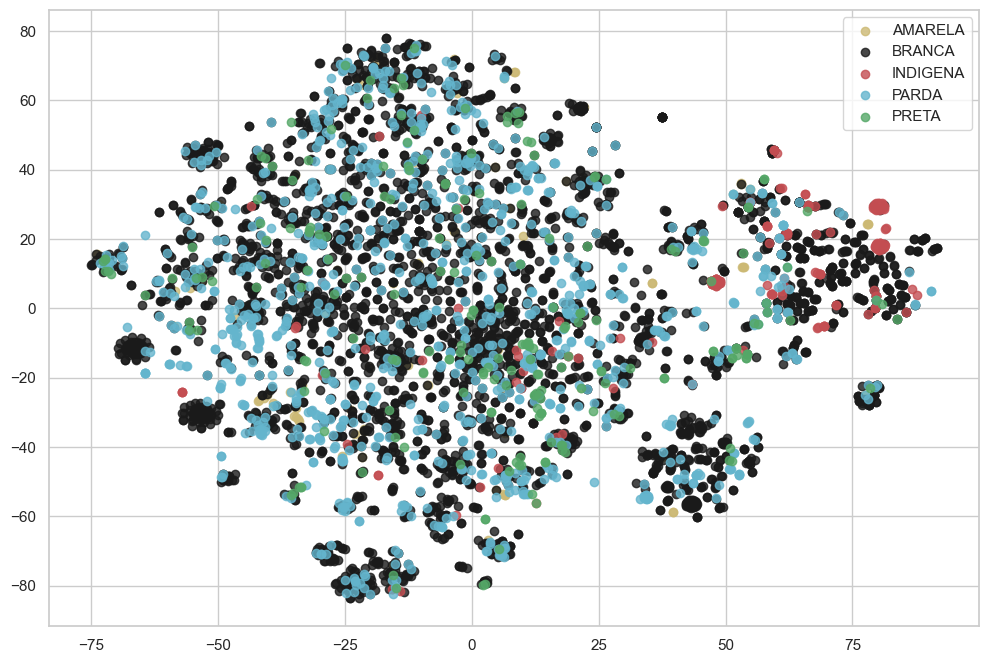

In [91]:

tsne_plot(X, y) 

In [92]:

# Scaling the data to make it suitable for the auto-encoder 
X_scaled = MinMaxScaler().fit_transform(X) 
X_amarela_scaled = X_scaled[y == 0] 
X_branca_scaled = X_scaled[y == 1] 
X_indigena_scaled = X_scaled[y == 2] 
X_parda_scaled = X_scaled[y == 3] 
X_preta_scaled = X_scaled[y == 4] 

In [93]:
# Building the Input Layer 
input_layer = Input(shape =(X.shape[1], )) 

# Building the Encoder network 
encoded = Dense(100, activation ='relu', 
				activity_regularizer = regularizers.l1(10e-5))(input_layer) 
encoded = Dense(50, activation ='relu', 
				activity_regularizer = regularizers.l1(10e-5))(encoded) 
encoded = Dense(25, activation ='relu', 
				activity_regularizer = regularizers.l1(10e-5))(encoded) 
encoded = Dense(12, activation ='relu', 
				activity_regularizer = regularizers.l1(10e-5))(encoded) 
encoded = Dense(6, activation ='relu')(encoded) 

# Building the Decoder network 
decoded = Dense(12, activation ='relu')(encoded) 
decoded = Dense(25, activation ='relu')(decoded) 
decoded = Dense(50, activation ='relu')(decoded) 
decoded = Dense(100, activation ='relu')(decoded) 

# Building the Output Layer 
output_layer = Dense(X.shape[1], activation ='relu')(decoded) 


In [94]:

# Defining the parameters of the Auto-encoder network 
autoencoder = Model(input_layer, output_layer) 
autoencoder.compile(optimizer ="adam", loss ="mse") 
  
# Training the Auto-encoder network 
autoencoder.fit(X_scaled, X_scaled,   
                batch_size = 16, epochs = 10,  
                shuffle = True, validation_split = 0.20) 

Epoch 1/10
263/263 [==============================] - 12s 33ms/step - loss: 9.0867e-04 - val_loss: 7.8915e-04
Epoch 2/10
263/263 [==============================] - 8s 30ms/step - loss: 9.0829e-04 - val_loss: 7.8878e-04
Epoch 3/10
263/263 [==============================] - 10s 39ms/step - loss: 9.0791e-04 - val_loss: 7.8840e-04
Epoch 4/10
263/263 [==============================] - 10s 38ms/step - loss: 9.0753e-04 - val_loss: 7.8803e-04
Epoch 5/10
263/263 [==============================] - 9s 33ms/step - loss: 9.0716e-04 - val_loss: 7.8765e-04
Epoch 6/10
263/263 [==============================] - 9s 34ms/step - loss: 9.0678e-04 - val_loss: 7.8728e-04
Epoch 7/10
263/263 [==============================] - 9s 33ms/step - loss: 9.0640e-04 - val_loss: 7.8691e-04
Epoch 8/10
263/263 [==============================] - 9s 35ms/step - loss: 9.0603e-04 - val_loss: 7.8654e-04
Epoch 9/10
263/263 [==============================] - 9s 35ms/step - loss: 9.0565e-04 - val_loss: 7.8617e-04
Epoch 10/10
263/

In [95]:

hidden_representation = Sequential() 
hidden_representation.add(autoencoder.layers[0]) 
hidden_representation.add(autoencoder.layers[1]) 
hidden_representation.add(autoencoder.layers[2]) 
hidden_representation.add(autoencoder.layers[3]) 
hidden_representation.add(autoencoder.layers[4]) 

In [96]:
# Separating the points encoded by the Auto-encoder as normal and fraud 
amarela_hidden_rep = hidden_representation.predict(X_amarela_scaled) 
branca_hidden_rep = hidden_representation.predict(X_branca_scaled) 
indigena_hidden_rep = hidden_representation.predict(X_indigena_scaled) 
parda_hidden_rep = hidden_representation.predict(X_parda_scaled) 
preta_hidden_rep = hidden_representation.predict(X_preta_scaled) 
  
# Combining the encoded points into a single table  
encoded_X = np.append(branca_hidden_rep, indigena_hidden_rep,  axis = 0) 
encoded_X = np.append(encoded_X, parda_hidden_rep, axis = 0 )
encoded_X = np.append(encoded_X, preta_hidden_rep, axis = 0 )
encoded_X = np.append(encoded_X, amarela_hidden_rep, axis = 0 )


y_amarela = np.full(amarela_hidden_rep.shape[0], 0) 
y_branca = np.full(branca_hidden_rep.shape[0], 1) 
y_indigena = np.full(indigena_hidden_rep.shape[0], 2) 
y_parda = np.full(parda_hidden_rep.shape[0],3) 
y_preta = np.full(preta_hidden_rep.shape[0],4) 
 
encoded_y = np.append(y_branca, y_parda) 
encoded_y = np.append(encoded_y, y_amarela) 
encoded_y = np.append(encoded_y, y_indigena) 
encoded_y = np.append(encoded_y, y_preta) 
  


7/7 [==============================] - 0s 7ms/step


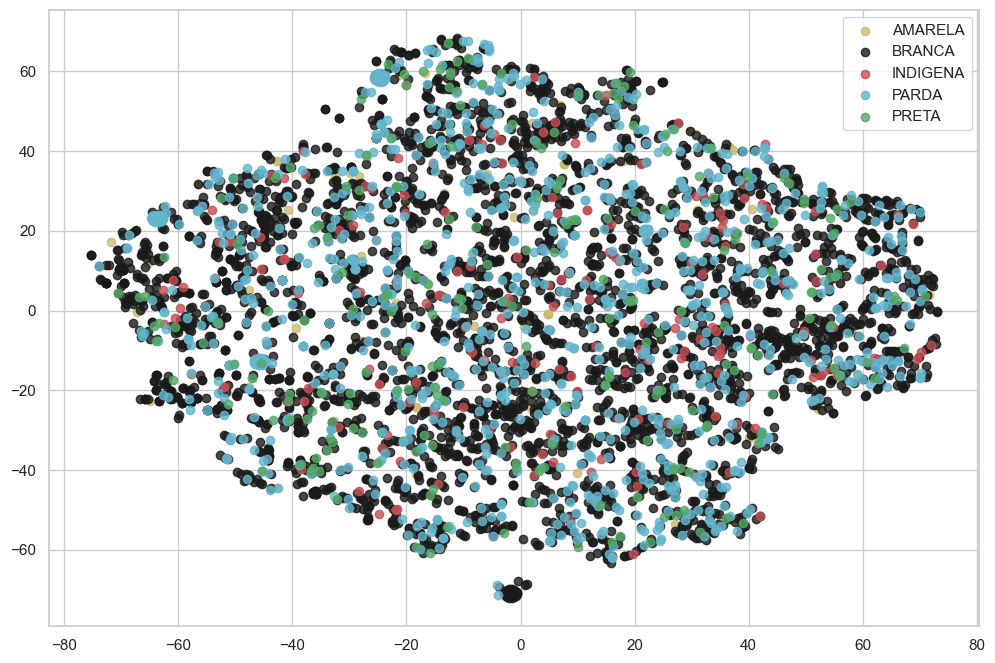

In [97]:
# Plotting the encoded points 
tsne_plot(encoded_X, encoded_y) 

In [98]:

# Splitting the encoded data for linear classification 
X_train_encoded, X_test_encoded, y_train_encoded, y_test_encoded = train_test_split(encoded_X, encoded_y, test_size = 0.2) 
  
# Splitting the original data for non-linear classification 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2) 

In [99]:
# Building the logistic regression model 
lrclf = LogisticRegression() 
lrclf.fit(X_train_encoded, y_train_encoded) 
  
# Storing the predictions of the linear model 
y_pred_lrclf = lrclf.predict(X_test_encoded) 
  
# Evaluating the performance of the linear model 
print('Accuracy : '+str(accuracy_score(y_test_encoded, y_pred_lrclf))) 

Accuracy : 0.7111534795042898


In [100]:

# # Building the SVM model 
# svmclf = SVC() 
# svmclf.fit(X_train, y_train) 
  
# # Storing the predictions of the non-linear model 
# y_pred_svmclf = svmclf.predict(X_test) 
  
# # Evaluating the performance of the non-linear model 
# print('Accuracy : '+str(accuracy_score(y_test, y_pred_svmclf))) 